#  Notebook 4 — Modelo con Mitigación de Sesgo
## HMDA New York 2024: Sesgo, Equidad y Explicabilidad en Hipotecas

**Autores:** Izan Cuesta Corbí · Dennis García Solera · Marcos Segurado Llopis · Jesús Cano Moya  
**Dataset:** Home Mortgage Disclosure Act (HMDA) — New York 2024 (CFPB)

---
> **Objetivo de este notebook:** Mitigar el sesgo demográfico del modelo LightGBM ganador mediante técnicas algorítmicas (*Fairlearn*). Evaluaremos el *trade-off* resultante entre rendimiento y equidad, y auditaremos con SHAP cómo se neutraliza la discriminación en las nuevas predicciones.

> `RANDOM_STATE = 42` fijado globalmente para reproducibilidad.

--- 

### Imports

In [2]:
import re
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score
)
import shap

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

/home/dgs75/anaconda3/envs/AA2026/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
---

## Conjunto de Datos

En este notebook cargamos los conjuntos de entrenamiento y test generados en el Notebook 1, ya preprocesados, imputados y escalados. Adicionalmente, aplicamos una limpieza de nombres de columnas para garantizar la compatibilidad con LightGBM, que no acepta caracteres especiales en los nombres de features. De esta forma, al partir de los mismos datos que los notebooks anteriores, cualquier diferencia en los resultados se le atribuye exclusivamente a la técnica de mitigación aplicada, no al preprocesamiento.

---

### Carga y limpieza del dataset

In [3]:
def limpiar_columnas(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

In [4]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

train = limpiar_columnas(train)
test  = limpiar_columnas(test)

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

train.head()

Train: (226665, 81)
Test:  (56667, 81)


,derived_msa_md,county_code,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open_end_line_of_credit,business_or_commercial_purpose,loan_amount,...,derived_race_Black_or_African_American,derived_race_Free_Form_Text_Only,derived_race_Joint,derived_race_Native_Hawaiian_or_Other_Pacific_Islander,derived_race_Race_Not_Available,derived_race_White,derived_sex_Female,derived_sex_Joint,derived_sex_Male,derived_sex_Sex_Not_Available
0,-0.053043,-0.136364,0.0,0.0,9.666667,1.0,0.0,1.0,0.0,-0.030303,...,False,False,False,False,False,True,False,True,False,False
1,5.598696,0.772727,0.0,0.0,-0.333333,0.0,0.0,0.0,0.0,-0.303030,...,False,False,False,False,False,True,False,False,True,False
2,-1.898609,-1.318182,0.0,0.0,0.666667,1.0,0.0,0.0,0.0,-0.545455,...,False,False,False,False,False,True,False,True,False,False
3,0.414435,-0.227273,0.0,0.0,-0.333333,0.0,0.0,0.0,1.0,-0.272727,...,False,False,False,False,True,False,False,False,False,True
4,0.000000,0.363636,0.0,0.0,9.666667,0.0,0.0,0.0,1.0,0.696970,...,False,False,False,False,True,False,True,False,False,False


---
### Selección de Columnas

Al igual que en el Notebook 3, incluimos todas las columnas disponibles como features, incluyendo los atributos sensibles (`derived_race_*`, `derived_sex_*`, `derived_ethnicity_*`). Esto es necesario porque el modelo mitigado necesita acceder a la variable sensible principal (`derived_race_White`) durante el entrenamiento para que Fairlearn pueda aplicar la restricción de *Equalized Odds* sobre ella.

In [55]:
SENSITIVE_COLS = [col for col in train.columns if 
                  col.startswith('derived_race_') or 
                  col.startswith('derived_sex_') or 
                  col.startswith('derived_ethnicity_')]

FEATURE_COLS = [col for col in train.columns if col != 'action_taken']

print(f"Nº de features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")
print(f"\nNº de features sensibles: {len(SENSITIVE_COLS)}")
print(f"Features: {SENSITIVE_COLS}")

Nº de features: 80
Features: ['derived_msa_md', 'county_code', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open_end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_term', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'income', 'debt_to_income_ratio', 'applicant_credit_score_type', 'co_applicant_credit_score_type', 'applicant_ethnicity_1', 'co_applicant_ethnicity_1', 'applicant_ethnicity_observed', 'co_applicant_ethnicity_observed', 'applicant_race_1', 'co_applicant_race_1', 'applicant_race_observed', 'co_applicant_race_observed', 'applicant_sex', 'co_applicant_sex', 'applicant_sex_observed', 'co_applicant_sex_observed', 'applicant_age', 'applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution', 'aus_1

---
### Separación de Train/Test

In [56]:
X_train = train[FEATURE_COLS] # columnas que entran al modelo 
y_train = train['action_taken'] # columna que queremos predecir

X_test = test[FEATURE_COLS] 
y_test = test['action_taken']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (226665, 80)
X_test:  (56667, 80)


---
---

## Comparativa de Modelos

---
### Mejor Modelo: LightGBM

Cargamos el modelo LightGBM optimizado guardado en el Notebook 3. Este modelo ya está entrenado con los hiperparámetros seleccionados mediante GridSearch, por lo que lo usamos directamente como estimador base para ``ExponentiatedGradient``, sin reentrenarlo desde cero.

In [57]:
modelo = joblib.load('../models/lightgbm.pkl')

In [58]:
resultados_comparacion = []

y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

resultados_comparacion.append({
    'Modelo': 'LightGBM Sesgado',
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'F1-Score': round(f1_score(y_test, y_pred), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
})

---

### Modelo con Mitigación de Sesgo

Aplicamos `ExponentiatedGradient` de Fairlearn sobre el LightGBM optimizado, usando `EqualizedOdds` como restricción de equidad. Esta técnica entrena iterativamente múltiples versiones del modelo base con distintos pesos por muestra, buscando el punto óptimo en el que las tasas de error se igualen entre el grupo `derived_race_White` y el resto. Usamos `_pmf_predict` en lugar de `predict_proba` para obtener las probabilidades del modelo mitigado, ya que Fairlearn no tiene  un método estándar de probabilidades al combinar internamente varios predictores ponderados.

In [59]:
# Variable sensible principal a analizar
sensitive_feature_train = X_train['derived_race_White']
sensitive_feature_test  = X_test['derived_race_White']

mitigador = ExponentiatedGradient(
    estimator=modelo,                   # Nuestro LightGBM previamente optimizado
    constraints=EqualizedOdds(),
    sample_weight_name='sample_weight'  # Parámetro necesario para integrarlo con LightGBM
)

# Entrenamiento del modelo mitigado
mitigador.fit(X_train, y_train, sensitive_features=sensitive_feature_train)

# Nuevas predicciones "equitativas"
# Usamos _pmf_predict en lugar de predict_proba para modelos mitigados por Fairlearn
y_pred_mitigado = mitigador.predict(X_test)
y_prob_mitigado = mitigador._pmf_predict(X_test)[:, 1]

resultados_comparacion.append({
    'Modelo': 'LightGBM Mitigado',
    'Accuracy': round(accuracy_score(y_test, y_pred_mitigado), 4),
    'F1-Score': round(f1_score(y_test, y_pred_mitigado), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_mitigado), 4)
})

---
### Comparación de Rendimiento

**Tabla Comparativa**

In [60]:
comparativa_sesgo = pd.DataFrame(resultados_comparacion).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(comparativa_sesgo)

,Modelo,Accuracy,F1-Score,ROC-AUC
0,LightGBM Sesgado,0.8621,0.9116,0.8868
1,LightGBM Mitigado,0.8622,0.9117,0.7803


La tabla comparativa muestra que la mitigación apenas afecta a las métricas globales de clasificación: Accuracy y F1-Score son prácticamente idénticos entre el modelo sesgado (0.8621 / 0.9116) y el mitigado (0.8622 / 0.9117), con diferencias inferiores a 0.001. Sin embargo, el ROC-AUC cae de 0.8868 a 0.7803, una reducción aproximada de 0.106 puntos. Estos resultados muestran que el modelo corregido mantiene el mismo rendimiento en las decisiones finales de aprobar o denegar, pero pierde cierta precisión al ordenar los riesgos matemáticos. Esta caída es el coste directo de imponer la restricción de *Equalized Odds*: al forzar al modelo a igualar las tasas de error entre grupos raciales, pierde parte de su capacidad discriminativa global.

**Curvas ROC**

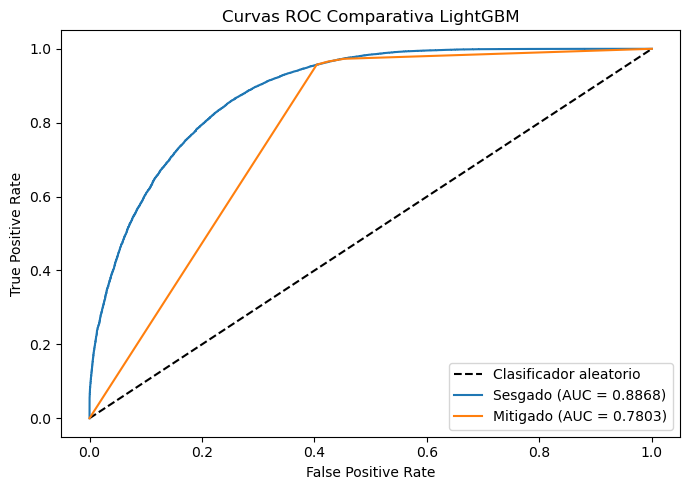

In [61]:
plt.figure(figsize=(7, 5))

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')

# Sesgado
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Sesgado (AUC = {auc_score:.4f})')

# Mitigado
fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_mitigado)
auc_score_m = roc_auc_score(y_test, y_prob_mitigado)
plt.plot(fpr_m, tpr_m, label=f'Mitigado (AUC = {auc_score_m:.4f})')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC Comparativa LightGBM')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/images/curva_roc_sesgos.png', dpi=300, bbox_inches='tight')
plt.show()

La comparativa de curvas ROC evidencia el *trade-off* central de la mitigación. La curva del mitigado muestra un comportamiento especialmente distinto en la zona de bajo FPR (0.0–0.4), donde el modelo sesgado despega rápidamente hacia TPR altos mientras el mitigado sube de forma más gradual. Esto indica que el modelo mitigado es menos capaz de identificar aprobaciones reales con alta precisión, pero lo hace de forma más equitativa entre grupos.

**Matriz de Confusión**

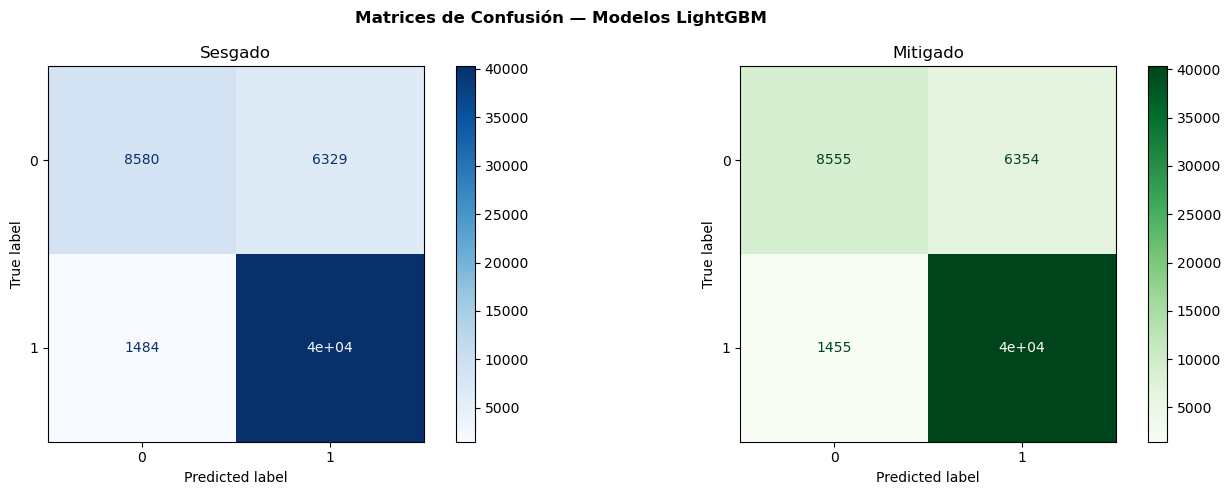

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrices de Confusión — Modelos LightGBM', fontweight='bold')

# Sesgado
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    ax=axes[0],
    colorbar=True,
    cmap='Blues'
)
axes[0].set_title("Sesgado")
axes[0].grid(False)

# Mitigado
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mitigado, 
    ax=axes[1],
    colorbar=True,
    cmap='Greens'
)
axes[1].set_title("Mitigado")
axes[1].grid(False)


plt.tight_layout()
plt.savefig('../outputs/images/matriz_confusion_sesgos.png', dpi=300, bbox_inches='tight')
plt.show()

Las matrices de confusión reflejan el mismo análisis de la tabla: a pesar de la caída en ROC-AUC, el rendimiento en predicción directa apenas varía. El modelo sesgado comete 1.484 falsos negativos (aprobaciones reales predichas como denegaciones) y 6.329 falsos positivos; el mitigado presenta 1.455 falsos negativos (-29) y 6.354 falsos positivos (+25). Las diferencias son mínimas en términos absolutos, lo que indica que el modelo mitigado clasifica de forma casi idéntica al sesgado cuando se evalúa globalmente. La caída de ROC-AUC no se traduce en peores decisiones individuales sino en una menor capacidad de ordenar probabilidades (algo que el umbral de clasificación fijo no captura). Esto refuerza la idea de que Accuracy y F1 no son métricas suficientes para detectar sesgo: dos modelos pueden tener matrices de confusión casi idénticas y diferir significativamente en equidad entre subgrupos.

---
---

## Fairness y Explicabilidad

---
### Análisis de Fairness

Evaluamos si la técnica de mitigación implementada logra neutralizar la discriminación estructural del LightGBM original. Mediante nuestra función de reporte, extraeremos la Tasa de Aprobación (*Demographic Parity*) junto con el TPR y FPR (*Equalized Odds*) para cada subgrupo demográfico representativo. Esto nos permitirá generar un contraste numérico directo entre las decisiones del modelo base y el mitigado, desglosado por raza, sexo y etnia.

In [63]:
sensitive_groups_test = test[SENSITIVE_COLS]

def fairness_report(y_true, y_pred, groups, sensitive_prefix):
    cols = [c for c in groups.columns if c.startswith(sensitive_prefix)]
    resultados = []
    for col in cols:
        mask = groups[col].reset_index(drop=True) == 1
        if mask.sum() < 50:
            continue
        yt = y_true.reset_index(drop=True)[mask]
        yp = pd.Series(y_pred)[mask]
        approval_rate = (yp == 1).mean()
        tp = ((yt == 1) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        nombre = col.replace(sensitive_prefix, '')
        resultados.append({
            'Grupo': nombre,
            'N': mask.sum(),
            'Approval Rate (DP)': round(approval_rate, 4),
            'TPR': round(tpr, 4),
            'FPR': round(fpr, 4)
        })
    return pd.DataFrame(resultados).sort_values('Approval Rate (DP)', ascending=False)

#### Fairness por raza

Modelo Sesgado

In [64]:
print("FAIRNESS — RAZA")
print("=" * 60)
df_raza = fairness_report(y_test, y_pred, sensitive_groups_test, 'derived_race_')
print(df_raza.to_string(index=False))

FAIRNESS — RAZA
                                    Grupo     N  Approval Rate (DP)    TPR    FPR
                                    Joint   953              0.8846 0.9755 0.4916
                                    White 35847              0.8525 0.9709 0.4648
                                    Asian  5135              0.8288 0.9736 0.3863
                       Race_Not_Available  9695              0.7888 0.9539 0.4102
                Black_or_African_American  4493              0.6686 0.9189 0.3166
         American_Indian_or_Alaska_Native   249              0.5743 0.8923 0.2269
                 2_or_more_minority_races   141              0.5461 0.8082 0.2647
Native_Hawaiian_or_Other_Pacific_Islander   130              0.5154 0.8841 0.0984


Modelo Mitigado

In [65]:
print("FAIRNESS — RAZA")
print("=" * 60)
df_raza_m = fairness_report(y_test, y_pred_mitigado, sensitive_groups_test, 'derived_race_')
print(df_raza_m.to_string(index=False))

FAIRNESS — RAZA
                                    Grupo     N  Approval Rate (DP)    TPR    FPR
                                    Joint   953              0.8940 0.9819 0.5140
                                    White 35847              0.8413 0.9641 0.4393
                                    Asian  5135              0.8411 0.9806 0.4147
                       Race_Not_Available  9695              0.8098 0.9686 0.4458
                Black_or_African_American  4493              0.7042 0.9474 0.3621
         American_Indian_or_Alaska_Native   249              0.6024 0.9077 0.2689
                 2_or_more_minority_races   141              0.5957 0.8767 0.2941
Native_Hawaiian_or_Other_Pacific_Islander   130              0.5538 0.9275 0.1311


Tras la mitigación, la brecha racial se reduce de forma moderada pero consistente. La tasa de aprobación de personas negras o afroamericanas (``Black_or_African_American``) sube del 66.86% al 70.42% (+3.56%), y la de ``American_Indian_or_Alaska_Native`` del 57.43% al 60.24% (+2.81%). La brecha entre el grupo más favorecido (``Joint``, 89.40%) y el menos favorecido (``Native_Hawaiian_or_Other_Pacific_Islander``, 55.38%) se mantiene amplia (34% aprox.), lo que indica que ``ExponentiatedGradient`` consigue una mejora real pero parcial: redistribuye parte del privilegio del grupo blanco hacia los grupos minoritarios sin eliminarlo por completo. Significativamente, la tasa de aprobación de personas blancas baja ligeramente del 85.25% al 84.13%, lo que refleja el mecanismo de la restricción *Equalized Odds*: nivelar implica ceder algo en el grupo dominante.

#### Fairness por sexo

Modelo Sesgado

In [66]:
print("FAIRNESS — SEXO")
print("=" * 60)
df_sexo = fairness_report(y_test, y_pred, sensitive_groups_test, 'derived_sex_')
print(df_sexo.to_string(index=False))

FAIRNESS — SEXO
            Grupo     N  Approval Rate (DP)    TPR    FPR
            Joint 18386              0.8863 0.9764 0.5101
Sex_Not_Available  4940              0.8225 0.9626 0.4640
             Male 19860              0.7916 0.9584 0.3977
           Female 13481              0.7806 0.9553 0.3751


Modelo Mitigado

In [67]:
print("FAIRNESS — SEXO")
print("=" * 60)
df_sexo_m = fairness_report(y_test, y_pred_mitigado, sensitive_groups_test, 'derived_sex_')
print(df_sexo_m.to_string(index=False))

FAIRNESS — SEXO
            Grupo     N  Approval Rate (DP)    TPR    FPR
            Joint 18386              0.8864 0.9769 0.5084
Sex_Not_Available  4940              0.8415 0.9730 0.5050
             Male 19860              0.7896 0.9564 0.3957
           Female 13481              0.7805 0.9567 0.3717


La mitigación tiene un efecto mínimo sobre las disparidades por sexo, que ya eran las más reducidas en en el notebook anterior. Las tasas de hombres (79.16% → 78.96%) y mujeres (78.06% → 78.05%) permanecen prácticamente inalteradas, lo que tiene sentido: la restricción se aplicó exclusivamente sobre ``derived_race_White`` como atributo sensible principal, por lo que el modelo no recibe presión directa para corregir las disparidades de sexo. El grupo ``Sex_Not_Available`` sí muestra una mejora notable (82.25% → 84.15%), probablemente como efecto indirecto de la redistribución de pesos internos del modelo.

#### Fairness por etnia

Modelo Sesgado

In [68]:
print("FAIRNESS — ETNIA")
print("=" * 60)
df_etnia = fairness_report(y_test, y_pred, sensitive_groups_test, 'derived_ethnicity_')
print(df_etnia.to_string(index=False))

FAIRNESS — ETNIA
                  Grupo     N  Approval Rate (DP)    TPR    FPR
                  Joint  1200              0.8400 0.9706 0.4170
 Not_Hispanic_or_Latino 41660              0.8392 0.9685 0.4422
Ethnicity_Not_Available  8891              0.8051 0.9589 0.4313
     Hispanic_or_Latino  4891              0.7078 0.9333 0.3166


Modelo Mitigado

In [69]:
print("FAIRNESS — ETNIA")
print("=" * 60)
df_etnia_m = fairness_report(y_test, y_pred_mitigado, sensitive_groups_test, 'derived_ethnicity_')
print(df_etnia_m.to_string(index=False))

FAIRNESS — ETNIA
                  Grupo     N  Approval Rate (DP)    TPR    FPR
 Not_Hispanic_or_Latino 41660              0.8369 0.9672 0.4366
                  Joint  1200              0.8358 0.9706 0.3993
Ethnicity_Not_Available  8891              0.8238 0.9708 0.4664
     Hispanic_or_Latino  4891              0.7060 0.9314 0.3149


Los resultados por etnia muestran un efecto de mitigación muy contenido. Las personas hispanas o latinas (``Hispanic_or_Latino``) pasan del 70.78% al 70.60%, una variación prácticamente nula (-0.18%), lo que confirma que la restricción centrada en ``derived_race_White`` apenas arrastra mejoras para este grupo. La brecha entre no hispanos (83.69%) e hispanos (70.60%) se mantiene aproximadamente en un 13%, idéntica a la del modelo sesgado. Esto refleja una limitación importante del enfoque: mitigar sobre un único atributo sensible binario (*White*/*no-White*) no generaliza automáticamente a otras dimensiones de desigualdad como la etnia.

#### Visualización

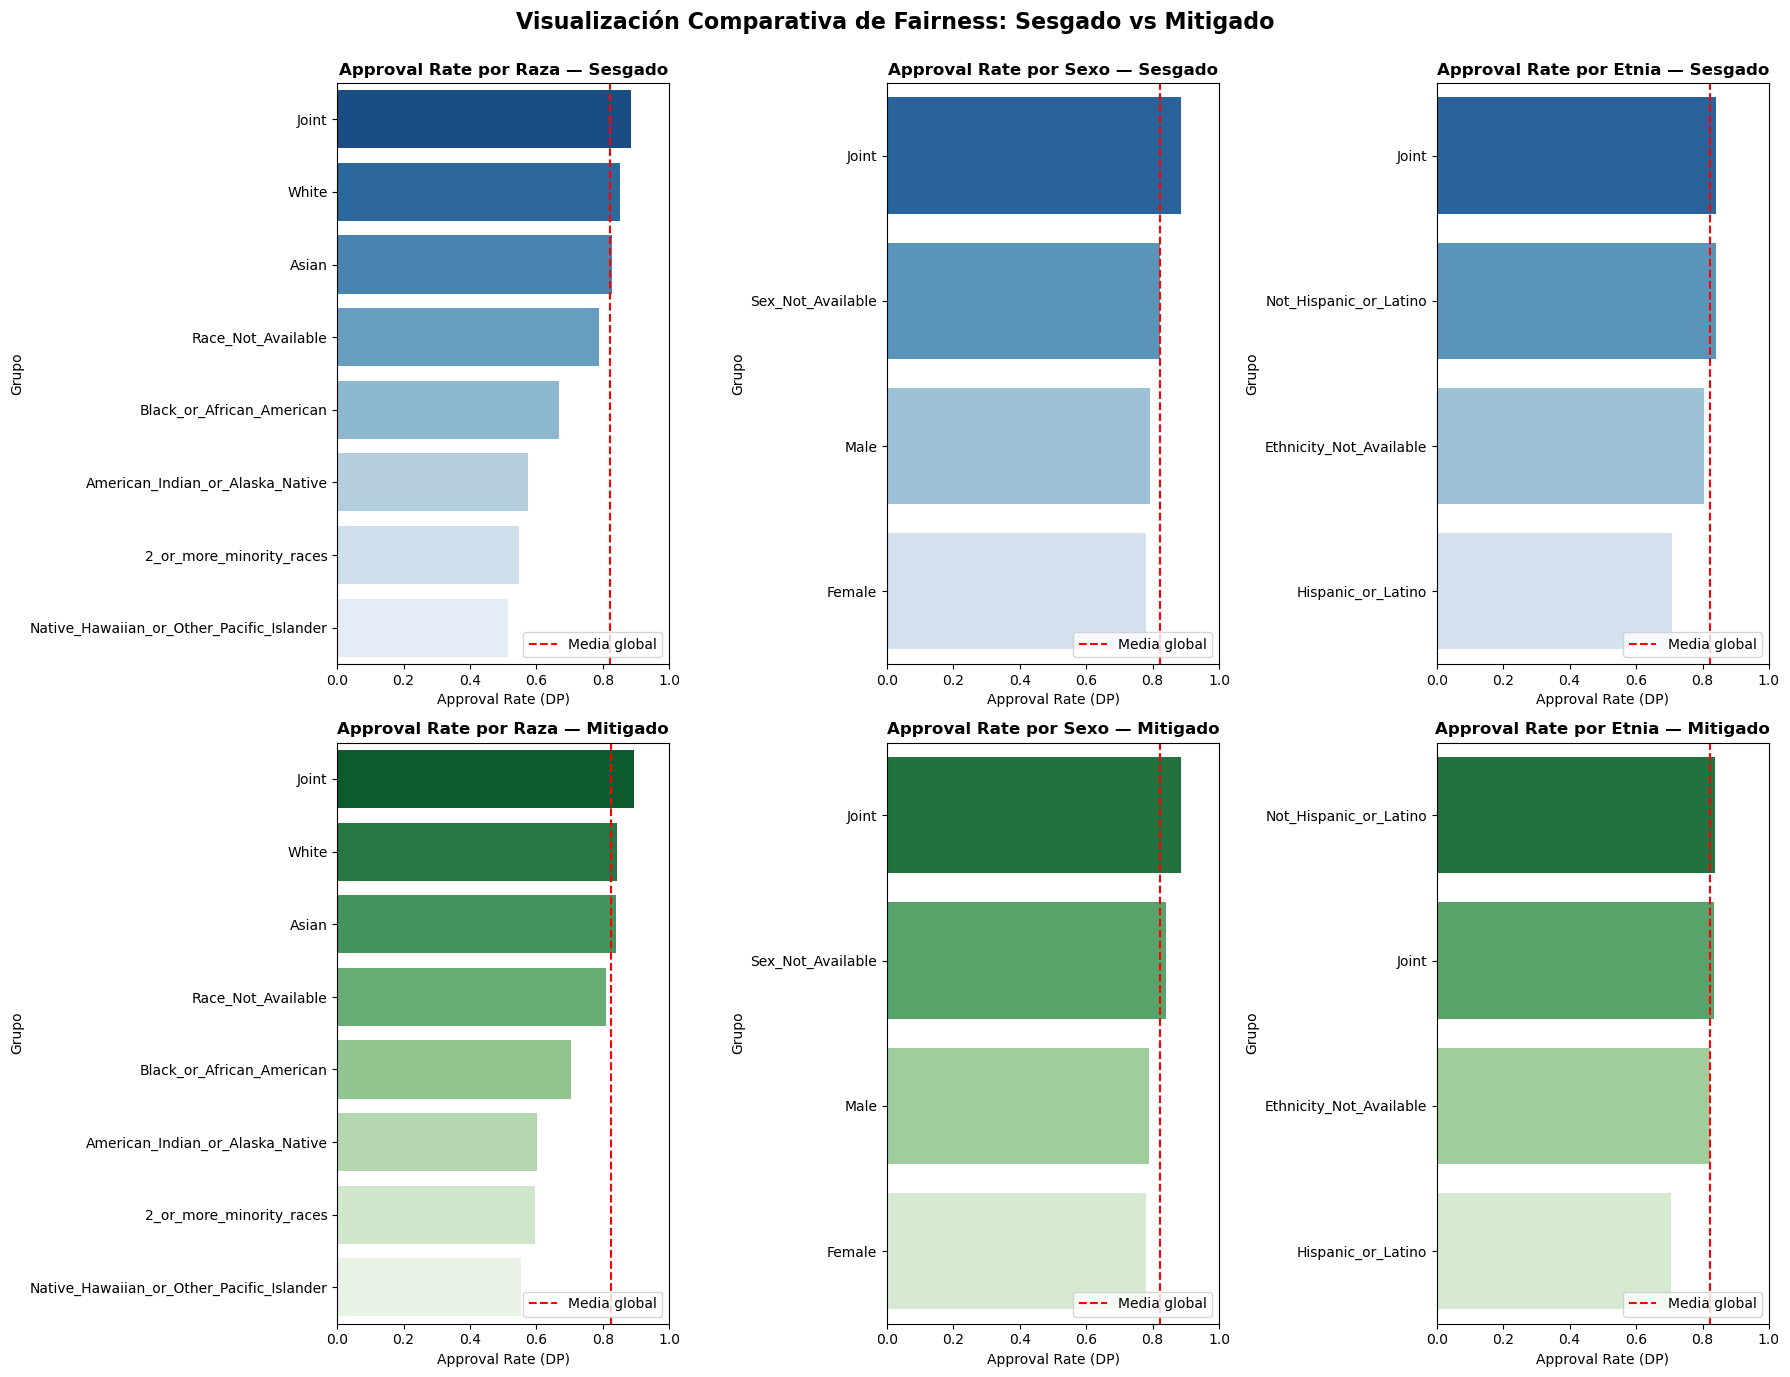

In [70]:
# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
fig.suptitle('Visualización Comparativa de Fairness: Sesgado vs Mitigado\n', fontweight='bold', fontsize=16)

configuraciones_plots = [
    # Sesgado
    (df_raza,  'Approval Rate por Raza — Sesgado',  y_pred.mean(), 'Blues_r'),
    (df_sexo,  'Approval Rate por Sexo — Sesgado',  y_pred.mean(), 'Blues_r'),
    (df_etnia, 'Approval Rate por Etnia — Sesgado', y_pred.mean(), 'Blues_r'),
    
    # Mitigado
    (df_raza_m,  'Approval Rate por Raza — Mitigado',  y_pred_mitigado.mean(), 'Greens_r'),
    (df_sexo_m,  'Approval Rate por Sexo — Mitigado',  y_pred_mitigado.mean(), 'Greens_r'),
    (df_etnia_m, 'Approval Rate por Etnia — Mitigado', y_pred_mitigado.mean(), 'Greens_r')
]

# Recorremos los 6 lienzos aplanando la matriz con .flatten()
for ax, (df_group, titulo, media_global, paleta) in zip(axes.flatten(), configuraciones_plots):
    sns.barplot(data=df_group, x='Approval Rate (DP)', y='Grupo', ax=ax, palette=paleta)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlim(0, 1)
    
    # Línea roja para ver cómo de lejos está cada grupo de la media de aprobación
    ax.axvline(x=media_global, color='red', linestyle='--', label='Media global')
    ax.legend(loc='lower right')

# Ajustes estéticos finales
plt.tight_layout()
plt.savefig('../outputs/images/fairness_sesgos.png', dpi=300, bbox_inches='tight')
plt.show()

Este gráfico permite comparar visualmente el efecto de la mitigación en los tres atributos sensibles. En raza (``derived_race``), las barras de los grupos minoritarios se desplazan ligeramente hacia la derecha en el panel inferior (mitigado), reduciendo su distancia respecto a la línea roja de media global. En sexo (``derived_sex``), los paneles superior e inferior son prácticamente idénticos, confirmando la ausencia de efecto. En etnia (``derived_ethnicity``), el grupo ``Hispanic_or_Latino`` apenas varía. 

La conclusión visual es clara: la mitigación mejora selectivamente donde se aplicó la restricción (``derived_race``), sin propagarse de forma significativa al resto de dimensiones demográficas.

---
### Explicabilidad — Valores SHAP

Como establecimos en el notebook anterior, los valores SHAP son esenciales para auditar la lógica detrás de cada decisión hipotecaria. En esta fase, nuestro objetivo principal es comprobar visual y matemáticamente que las variables protegidas han perdido su poder de influencia injusta sobre el algoritmo. Sin embargo, la extracción de estas métricas presenta ahora un desafío técnico: dado que el mitigador de *Fairlearn* no es un árbol único, sino un meta-modelo que agrupa internamente varios clasificadores LightGBM, la función estándar `TreeExplainer` falla si intentamos aplicarla a la "caja" entera. Para resolverlo, debemos iterar sobre la estructura interna, calcular los valores SHAP de cada sub-modelo por separado y construir la matriz final realizando una media ponderada basada en los pesos asignados por el mitigador.

Sesgado

In [71]:
# Calculamos los valores SHAP sobre una muestra de X_test para reducir tiempo
# 1000 muestras es suficiente para obtener una visión representativa
X_test_sample = X_test.sample(1000, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test_sample)

print("Valores SHAP calculados")

Valores SHAP calculados


Mitigado

In [72]:
# Calculamos los valores SHAP sobre una muestra de X_test para reducir tiempo
# 1000 muestras es suficiente para obtener una visión representativa
X_test_sample = X_test.sample(1000, random_state=RANDOM_STATE)

shap_values_mitigado = np.zeros(X_test_sample.shape)

# Calcular el SHAP ponderado de los sub-modelos de Fairlearn
for predictor, peso in zip(mitigador.predictors_, mitigador.weights_):
    
    explainer = shap.TreeExplainer(predictor)
    sv = explainer.shap_values(X_test_sample)
    
    # Si devuelve lista, cogemos la clase 1 (pesos de aprobación)
    if isinstance(sv, list):
        sv = sv[1]
        
    # Media ponderada según pesos
    shap_values_mitigado += sv * peso

print("Valores SHAP calculados")

Valores SHAP calculados


#### Summary Plot

Sesgado

In [73]:
# Summary plot — importancia global de features
plt.figure()
shap.summary_plot(
    shap_values, X_test_sample,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — LightGBM Sesgado')
plt.tight_layout()
plt.savefig('../outputs/images/shap_summary_sesgado.png', dpi=300, bbox_inches='tight')
plt.close()

Mitigado

In [74]:
# Summary plot — importancia global de features
plt.figure()
shap.summary_plot(
    shap_values_mitigado, X_test_sample,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — LightGBM Mitigado')
plt.tight_layout()
plt.savefig('../outputs/images/shap_summary_mitigado.png', dpi=300, bbox_inches='tight')
plt.close()

Comparativo

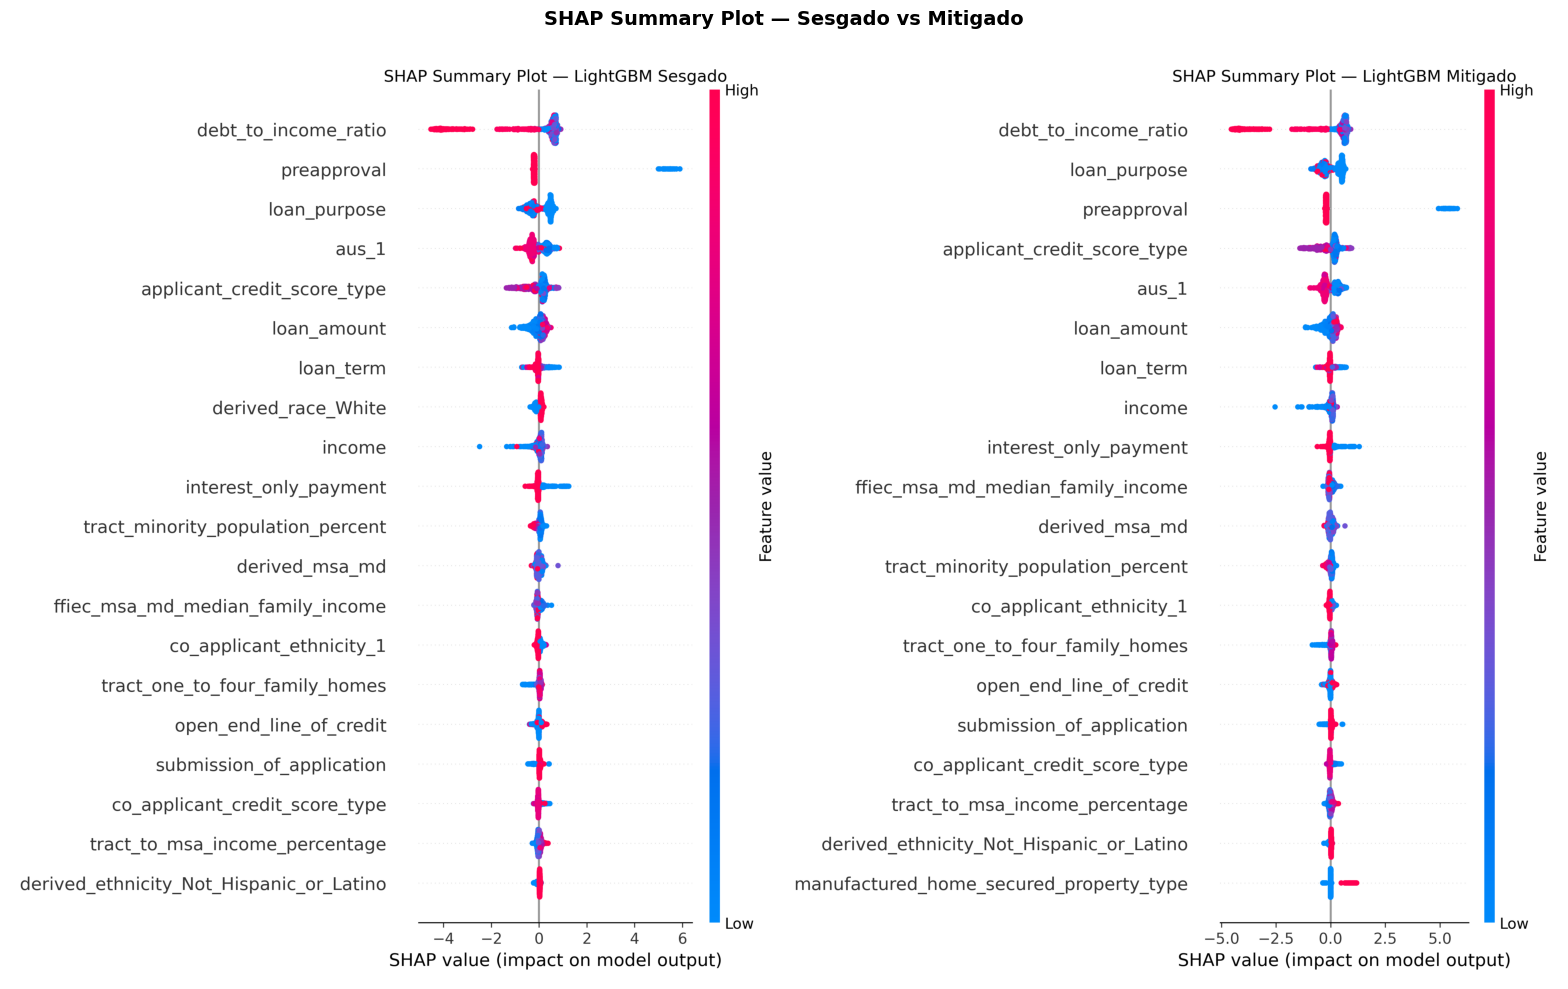

In [77]:
img_seg = Image.open('../outputs/images/shap_summary_sesgado.png')
img_mit = Image.open('../outputs/images/shap_summary_mitigado.png')

h = max(img_seg.height, img_mit.height)
w_total = img_seg.width + img_mit.width

combinada = Image.new('RGB', (w_total, h + 60), color='white')
combinada.paste(img_seg, (0, 60))
combinada.paste(img_mit, (img_seg.width, 60))


fig_final, ax = plt.subplots(figsize=(20, 10))
ax.imshow(combinada)
ax.axis('off')
ax.set_title('SHAP Summary Plot — Sesgado vs Mitigado', fontweight='bold', fontsize=14, pad=12)

plt.tight_layout()
plt.savefig('../outputs/images/shap_summary_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

Tal y como vemos en el gráfico comparativo, el *Summary Plot* del modelo mitigado mantiene ``debt_to_income_ratio`` como feature dominante, con el mismo patrón direccional que en Notebook 3: valores altos empujan hacia la denegación y valores bajos hacia la aprobación. La diferencia más relevante respecto al modelo sesgado es el desplazamiento de ``derived_race_White``: mientras que en el caso sesgado aparece en posición 8 con un impacto visible; en el mitigado desciende en el ranking y su distribución de puntos se comprime hacia el centro, indicando que el modelo le asigna menos peso decisional. Por su parte, ``preapproval`` mantiene su impacto positivo extremo, aunque la escala del eje X se reduce (de ±6 a ±5), reflejando que el modelo mitigado distribuye el peso predictivo de forma más homogénea entre features.

#### Bar Plot Comparativo

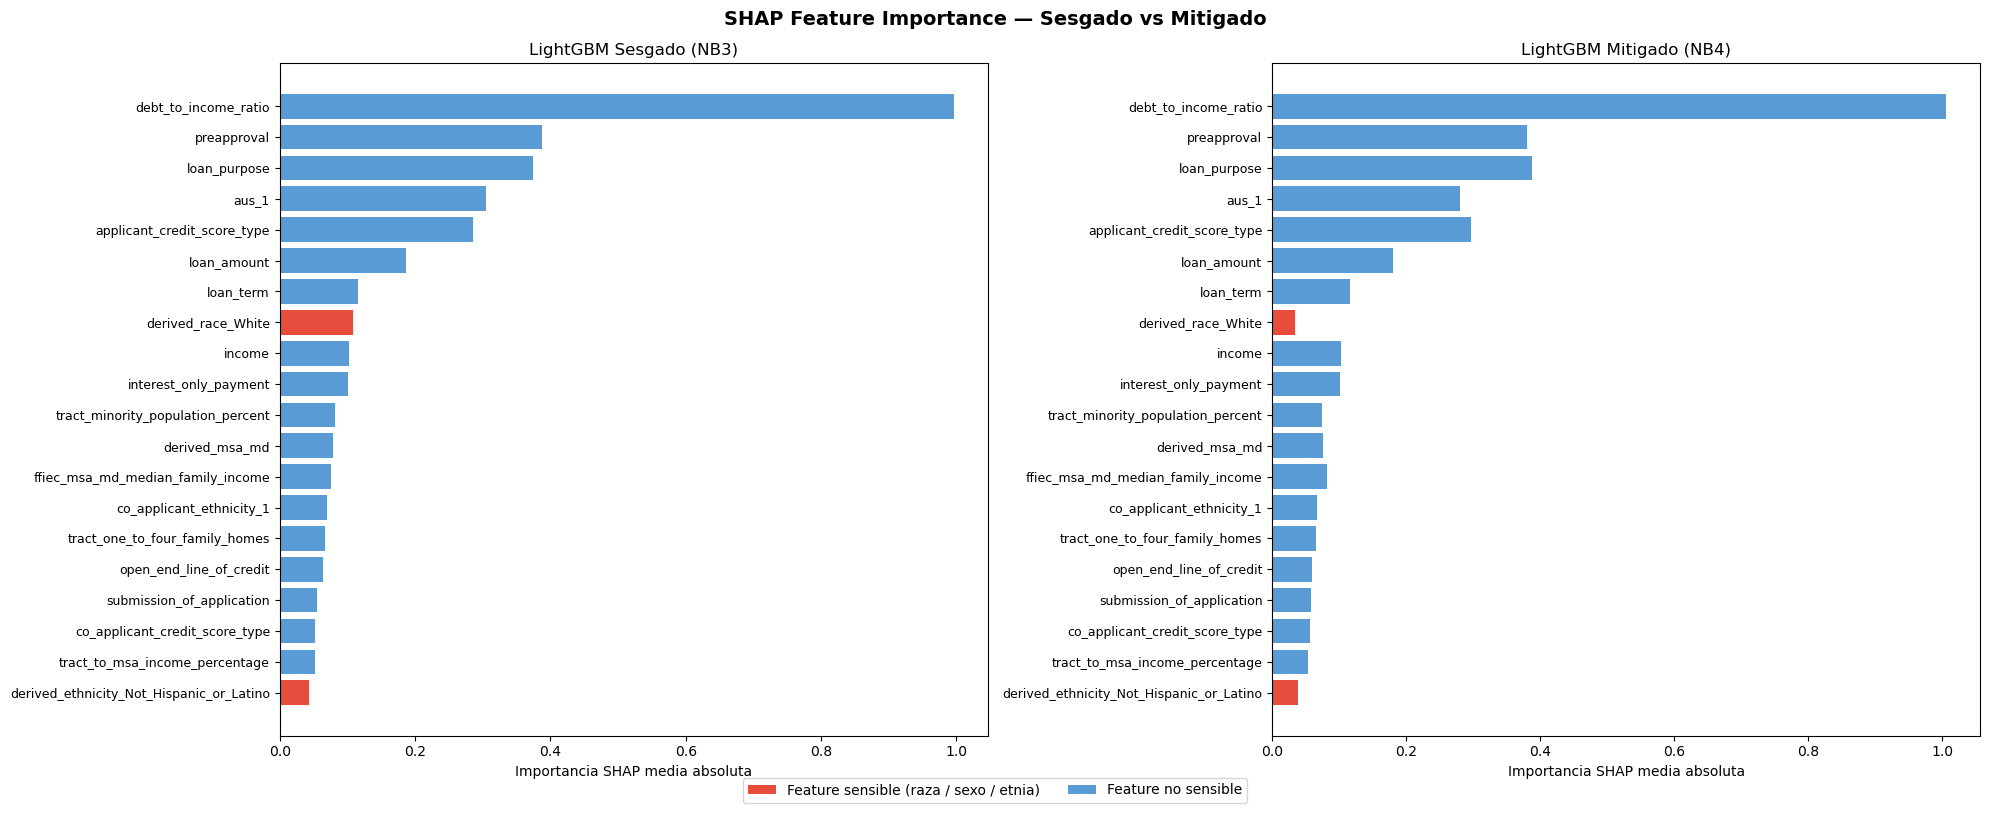

In [78]:
importancia_sesgado  = pd.Series(np.abs(shap_values).mean(axis=0),          index=X_test_sample.columns)
importancia_mitigado = pd.Series(np.abs(shap_values_mitigado).mean(axis=0), index=X_test_sample.columns)

top_features = importancia_sesgado.sort_values(ascending=False).head(20).index.tolist()
top_features_inv = top_features[::-1]  

imp_seg = importancia_sesgado[top_features_inv].values
imp_mit = importancia_mitigado[top_features_inv].values

def get_colores(features):
    return ['#e74c3c' if 'derived_race' in f or 'derived_ethnicity' in f or 'derived_sex' in f 
            else '#5B9BD5' for f in features]

colores = get_colores(top_features_inv)
y_pos   = range(len(top_features_inv))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('SHAP Feature Importance — Sesgado vs Mitigado', fontweight='bold', fontsize=14)

# Sesgado
axes[0].barh(y_pos, imp_seg, color=colores)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_features_inv, fontsize=9)
axes[0].set_title('LightGBM Sesgado (NB3)', fontsize=12)
axes[0].set_xlabel('Importancia SHAP media absoluta')

# Mitigado 
axes[1].barh(y_pos, imp_mit, color=colores)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top_features_inv, fontsize=9)  # etiquetas también aquí
axes[1].set_title('LightGBM Mitigado (NB4)', fontsize=12)
axes[1].set_xlabel('Importancia SHAP media absoluta')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Feature sensible (raza / sexo / etnia)'),
    Patch(facecolor='#5B9BD5', label='Feature no sensible')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('../outputs/images/shap_bar_comparativo.png', dpi=300, bbox_inches='tight')
plt.show()

Podemos observar cómo el *Bar Plot Comparativo* cuantifica con precisión el efecto de la mitigación sobre ``derived_race_White`` (marcada en rojo). En el caso sesgado, su importancia media absoluta era aproximadamente de 0.10 (8ª posición). Tras la mitigación, esa importancia cae aproximadamente a 0.03 (reduciéndose a menos de un tercio). Esta es la evidencia SHAP más directa: el modelo toma decisiones apoyándose mucho menos en la raza del solicitante. En contraposición, las features financieras mantienen (o incluso incrementan) el dominio sobre la decisión, estableciendo así una lógica coherente tanto para el contexto financiero como para el social (reducción del sesgo demográfico).

---
---
## Conclusión Final

### Tabla resumen Final

In [5]:
tabla_resumen = pd.DataFrame([
    {
        'Modelo':             'Baseline (Regresión Logística)',
        'Accuracy':           0.7120,
        'F1-Score':           0.7874,
        'ROC-AUC':            0.7697,
        'Approval Rate White':  '66.85%',
        'Approval Rate Black':  '32.29%',
        'Brecha Racial (pp)':   34.56,
        'Approval Rate Hispanic': '40.61%',
        'Brecha Étnica (pp)':    24.39,
    },
    {
        'Modelo':             'LightGBM Sesgado',
        'Accuracy':           0.8621,
        'F1-Score':           0.9116,
        'ROC-AUC':            0.8868,
        'Approval Rate White':  '85.25%',
        'Approval Rate Black':  '66.86%',
        'Brecha Racial (pp)':   18.39,
        'Approval Rate Hispanic': '70.78%',
        'Brecha Étnica (pp)':    13.14,
    },
    {
        'Modelo':             'LightGBM Mitigado',
        'Accuracy':           0.8622,
        'F1-Score':           0.9117,
        'ROC-AUC':            0.7803,
        'Approval Rate White':  '84.13%',
        'Approval Rate Black':  '70.42%',
        'Brecha Racial (pp)':   13.71,
        'Approval Rate Hispanic': '70.60%',
        'Brecha Étnica (pp)':    13.53,
    },
])

tabla_resumen = tabla_resumen.set_index('Modelo')
display(tabla_resumen)

,Accuracy,F1-Score,ROC-AUC,Approval Rate White,Approval Rate Black,Brecha Racial (pp),Approval Rate Hispanic,Brecha Étnica (pp)
Modelo,,,,,,,,
Baseline (Regresión Logística),0.7120,0.7874,0.7697,66.85%,32.29%,34.56,40.61%,24.39
LightGBM Sesgado,0.8621,0.9116,0.8868,85.25%,66.86%,18.39,70.78%,13.14
LightGBM Mitigado,0.8622,0.9117,0.7803,84.13%,70.42%,13.71,70.60%,13.53


### Gráfico Trade-off

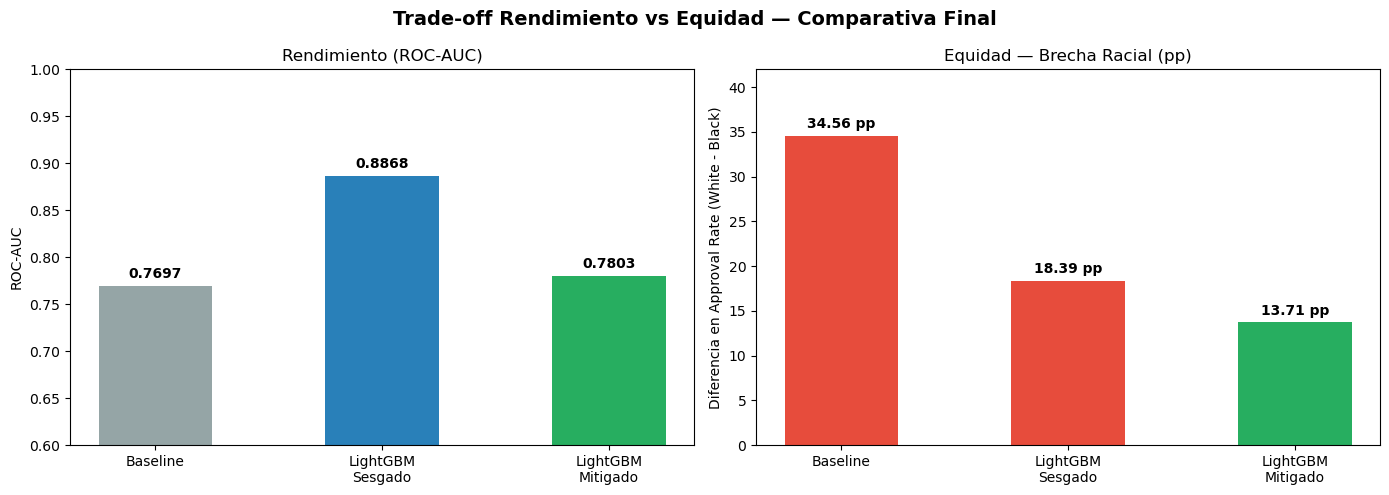

In [7]:
modelos   = ['Baseline', 'LightGBM\nSesgado', 'LightGBM\nMitigado']
roc_auc   = [0.7697, 0.8868, 0.7803]
brecha    = [34.56,  18.39,  13.71]
colores_roc    = ['#95a5a6', '#2980b9', '#27ae60']
colores_brecha = ['#e74c3c', '#e74c3c', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trade-off Rendimiento vs Equidad — Comparativa Final', fontweight='bold', fontsize=14)

# ROC-AUC
bars = axes[0].bar(modelos, roc_auc, color=colores_roc, width=0.5)
axes[0].set_ylim(0.6, 1.0)
axes[0].set_title('Rendimiento (ROC-AUC)', fontsize=12)
axes[0].set_ylabel('ROC-AUC')
for bar, val in zip(bars, roc_auc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Brecha racial
bars2 = axes[1].bar(modelos, brecha, color=colores_brecha, width=0.5)
axes[1].set_ylim(0, 42)
axes[1].set_title('Equidad — Brecha Racial (pp)', fontsize=12)
axes[1].set_ylabel('Diferencia en Approval Rate (White - Black)')
for bar, val in zip(bars2, brecha):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f} pp', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/images/tradeoff_final.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusión Final

La tabla y el gráfico resumen condensan el recorrido completo del proyecto y la evidencia interpretable definitiva sobre el *trade-off* central de nuestro estudio.

El baseline de Regresión Logística partía de un rendimiento moderado (ROC-AUC 0.7697) pero con una brecha racial de 34.56 pp (la más alta de los tres modelos) lo que evidencia que incluso un modelo simple discrimina estructuralmente cuando los datos reflejan desigualdades históricas. El LightGBM sesgado maximiza el rendimiento (ROC-AUC 0.8868) a costa de mantener una brecha racial de 18.39 pp, reduciéndola respecto al baseline no por diseño sino como efecto secundario de un mejor ajuste global. Es el modelo más preciso, pero también el que más activamente utiliza la raza como variable predictiva, tal y como confirma el análisis SHAP: `derived_race_White` aparece en posición 8 del ranking global con una importancia media absoluta de ~0.10.

El LightGBM mitigado representa la decisión de diseño central del proyecto: aceptar una caída de ROC-AUC hasta 0.7803 para reducir la brecha racial a 13.71 pp, la más baja de los tres. Accuracy y F1 se mantienen prácticamente idénticos al sesgado, lo que demuestra que el coste de la equidad no recae sobre la calidad de las decisiones individuales sino sobre la capacidad de ordenar probabilidades. Lo que ha logrado `ExponentiatedGradient` es aislar y neutralizar parcialmente el sesgo demográfico: la importancia SHAP de `derived_race_White` cae de ~0.10 a ~0.03, confirmando que el modelo toma sus decisiones sin apoyarse estructuralmente en la raza del solicitante. Las features estrictamente financieras (`debt_to_income_ratio`, `preapproval`, `loan_purpose` y `aus_1`) mantienen su dominio absoluto en ambos modelos, lo que confirma que la mitigación no ha distorsionado la lógica económica subyacente.

En el contexto regulatorio de concesión de hipotecas, donde la *Equal Credit Opportunity Act* y el *Fair Housing Act* exigen justificación de cada denegación, el modelo mitigado ofrece el equilibrio más defendible: rendimiento robusto, lógica financiera preservada y sesgo racial significativamente reducido.